# Projet 3 — Prédiction du Churn Client

## Introduction au Machine Learning

### Objectif

L'objectif de ce projet est de développer un modèle de Machine Learning capable de prédire le risque de résiliation d'un abonnement par un client d'une entreprise de télécommunications.

Nous allons :
- analyser la qualité des données ;
- nettoyer et préparer les données ;
- réaliser une analyse exploratoire ;
- développer plusieurs modèles de Machine Learning ;
- comparer leurs performances ;
- optimiser le meilleur modèle ;
- évaluer sa capacité à généraliser sur de nouvelles données.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
print("Les bibliothèques sont correctement importées.")

Les bibliothèques sont correctement importées.


In [2]:
import pandas as pd
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
possible_paths = [
    project_root / "data" / "WA_Fn-UseC_-Telco-Customer-Churn.csv",
    Path("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"),
    Path("data/WA_Fn-UseC_-Telco-Customer-Churn.csv"),
    Path.cwd() / "data" / "WA_Fn-UseC_-Telco-Customer-Churn.csv",
]

dataset_path = next((p for p in possible_paths if p.exists()), possible_paths[0])

df = pd.read_csv(dataset_path)
print(f"Dataset chargé : {dataset_path}")
print(df.head())

Dataset chargé : c:\Users\T-Plug\Desktop\Projet_3_Churn\data\WA_Fn-UseC_-Telco-Customer-Churn.csv
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic      

In [3]:
df.shape

(7043, 21)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

les valeurs manquantes

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

colonnes contiennent des valeurs manquantes.

In [9]:
df.isnull().sum().sort_values(ascending=False)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

les doublons

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["customerID"].duplicated().sum()

np.int64(0)

In [12]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

analyser TotalCharges comprendre pourquoi elle est en str

In [13]:
df["TotalCharges"].head(20)
df["TotalCharges"].value_counts().head(20)
df["TotalCharges"].apply(type).value_counts()

TotalCharges
<class 'str'>    7043
Name: count, dtype: int64

des valeurs vides ou des espaces dans cette colonne.

In [15]:

df["TotalCharges"].tail(20)

7023     6479.4
7024    3626.35
7025     1679.4
7026     403.35
7027     931.55
7028    4326.25
7029     263.05
7030      39.25
7031     3316.1
7032      75.75
7033    2625.25
7034    6886.25
7035     1495.1
7036      743.3
7037     1419.4
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: TotalCharges, dtype: str

In [16]:
df["TotalCharges"].head(20)

0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
15    7895.15
16    1022.95
17    7382.25
18     528.35
19     1862.9
Name: TotalCharges, dtype: str

In [17]:
df["TotalCharges"].str.strip().eq("").sum()

np.int64(11)

In [8]:
df["TotalCharges"] = df["TotalCharges"].str.strip()

In [9]:
df["TotalCharges"] = df["TotalCharges"].replace("", np.nan)

In [10]:
df["TotalCharges"].isnull().sum()

np.int64(11)

TotalCharges en véritable variable numérique.

In [11]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [12]:
df["TotalCharges"].dtype

dtype('float64')

In [13]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

qui sont ces clients et pourquoi leur TotalCharges est vide

In [14]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [15]:
df[df["TotalCharges"].isnull()][["customerID", "tenure", "Contract", "MonthlyCharges", "TotalCharges", "Churn"]]

,customerID,tenure,Contract,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,Two year,52.55,NaN,No
753,3115-CZMZD,0,Two year,20.25,NaN,No
936,5709-LVOEQ,0,Two year,80.85,NaN,No
1082,4367-NUYAO,0,Two year,25.75,NaN,No
1340,1371-DWPAZ,0,Two year,56.05,NaN,No
3331,7644-OMVMY,0,Two year,19.85,NaN,No
3826,3213-VVOLG,0,Two year,25.35,NaN,No
4380,2520-SGTTA,0,Two year,20.00,NaN,No
5218,2923-ARZLG,0,One year,19.70,NaN,No
6670,4075-WKNIU,0,Two year,73.35,NaN,No


In [16]:
df = df.dropna(subset=["TotalCharges"])

In [17]:
df.shape

(7032, 21)

### Traitement des valeurs manquantes

Après inspection de la colonne `TotalCharges`, 11 valeurs manquantes ont été identifiées.

Ces valeurs correspondent à des clients ayant une ancienneté (`tenure`) nulle. Comme `TotalCharges` représente le montant total facturé depuis le début de l'abonnement, aucune valeur fiable ne peut être déduite à partir des autres observations.

Les 11 lignes concernées ont donc été supprimées afin de conserver un jeu de données cohérent pour l'apprentissage des modèles.

In [18]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [19]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df["customerID"].duplicated().sum()

np.int64(0)

| Vérification               |    Résultat |
| -------------------------- | ----------: |
| Lignes initiales           |        7043 |
| Valeurs manquantes cachées |          11 |
| Lignes supprimées          |          11 |
| Lignes finales             |    **7032** |
| Colonnes                   |      **21** |
| Doublons                   |       **0** |
| `TotalCharges`             | **float64** |


Combien de clients sont partis et restés ?

In [22]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [23]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

## Répartition du Churn

Après le nettoyage des données, le jeu de données contient 7 032 clients.

- 5 163 clients (73,42 %) n'ont pas quitté l'entreprise.
- 1 869 clients (26,58 %) ont quitté l'entreprise.

La variable cible `Churn` présente donc une certaine asymétrie : les clients n'ayant pas quitté l'entreprise sont majoritaires. Cette caractéristique devra être prise en compte lors de l'évaluation des modèles de Machine Learning.

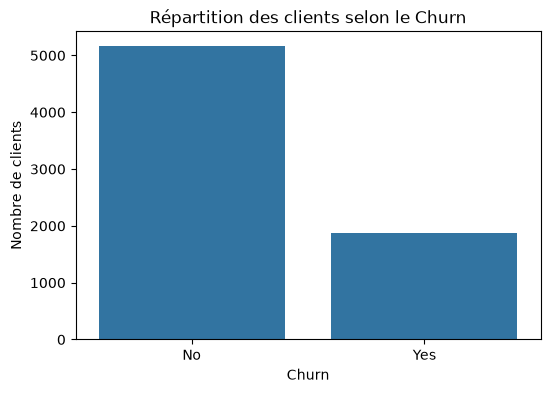

In [24]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Répartition des clients selon le Churn")
plt.xlabel("Churn")
plt.ylabel("Nombre de clients")

plt.show()

### Interprétation

La majorité des clients n'ont pas quitté l'entreprise (73,42 %), tandis que 26,58 % des clients ont résilié leur abonnement.

La variable cible `Churn` est donc déséquilibrée, avec une majorité de clients appartenant à la catégorie `No`. Cette particularité devra être prise en compte lors de l'entraînement et de l'évaluation des modèles, notamment en utilisant des métriques telles que la précision, le rappel et le F1-score.

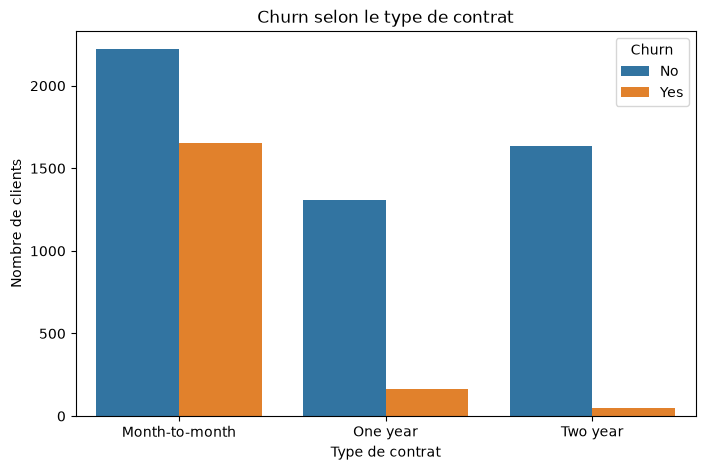

In [25]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Churn selon le type de contrat")
plt.xlabel("Type de contrat")
plt.ylabel("Nombre de clients")

plt.show()

### Churn selon le type de contrat

Le type de contrat semble fortement lié au churn.

Les clients ayant un contrat `Month-to-month` représentent la majorité des clients ayant quitté l'entreprise. À l'inverse, le nombre de clients ayant churné est beaucoup plus faible pour les contrats d'un an (`One year`) et de deux ans (`Two year`).

Cette première observation suggère que les clients engagés sur une durée plus longue sont moins susceptibles de quitter l'entreprise. Cette relation sera approfondie lors de l'analyse et de la modélisation.

In [26]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


Month-to-month → 42,71 % des clients partent.
 One year → seulement 11,28 % partent.
 Two year → seulement 2,85 % partent.

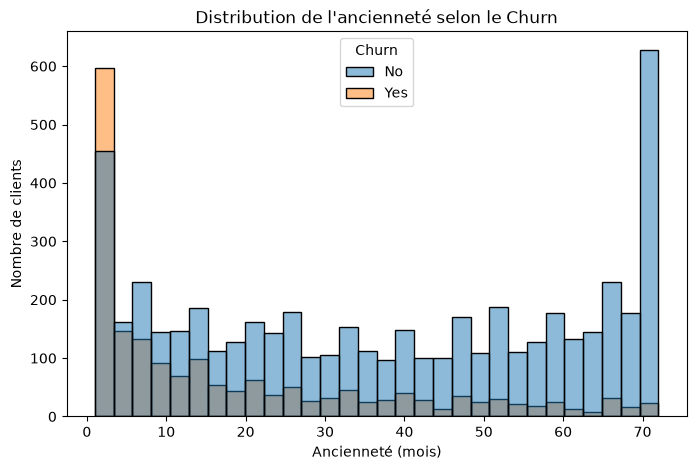

In [27]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30
)

plt.title("Distribution de l'ancienneté selon le Churn")
plt.xlabel("Ancienneté (mois)")
plt.ylabel("Nombre de clients")

plt.show()

### Churn selon l'ancienneté du client

La distribution de l'ancienneté montre que les clients ayant une faible ancienneté semblent davantage représentés parmi les clients ayant quitté l'entreprise.

À l'inverse, les clients ayant une ancienneté plus importante sont majoritairement restés dans l'entreprise.

L'ancienneté (`tenure`) semble donc être une variable pertinente pour la prédiction du churn. Cette relation sera prise en compte lors de la modélisation.

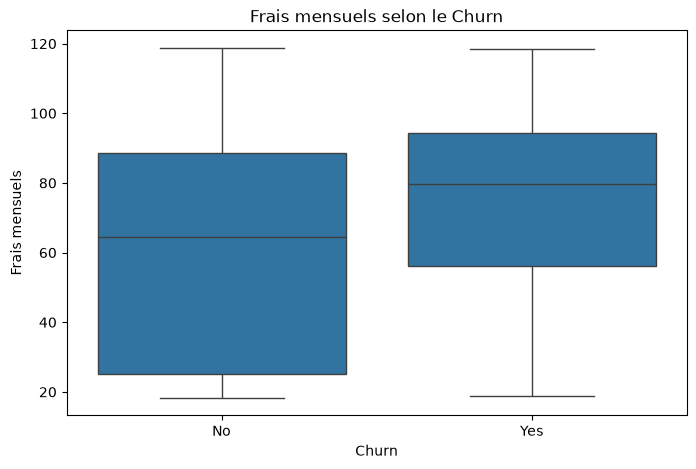

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Frais mensuels selon le Churn")
plt.xlabel("Churn")
plt.ylabel("Frais mensuels")

plt.show()

### Churn selon les frais mensuels

Le boxplot montre une différence entre les frais mensuels des clients ayant quitté l'entreprise et ceux étant restés.

La médiane des frais mensuels est plus élevée chez les clients ayant churné, autour de 80 €, contre environ 65 € pour les clients n'ayant pas churné.

Les clients ayant des frais mensuels plus élevés semblent donc présenter un risque de churn plus important. Cette variable pourra ainsi être utilisée lors de la modélisation.

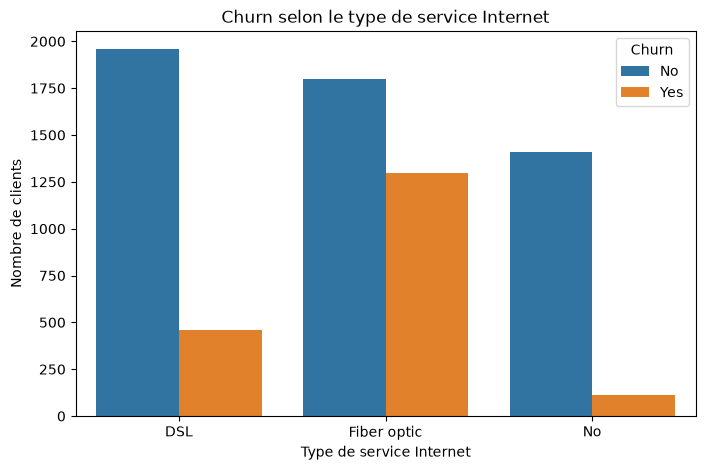

In [29]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Churn selon le type de service Internet")
plt.xlabel("Type de service Internet")
plt.ylabel("Nombre de clients")

plt.show()

In [30]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


Petit bilan de notre EDA jusqu'ici

On a déjà identifié 4 variables intéressantes :

Contract → très forte différence de churn selon la durée du contrat.
tenure → les clients avec une faible ancienneté semblent davantage concernés par le churn.
MonthlyCharges → les clients ayant churné ont généralement des frais mensuels plus élevés.
InternetService → le taux de churn est particulièrement élevé chez les clients Fiber optic.

Et c'est exactement le but de l'EDA : comprendre les données avant de donner les données au modèle.

In [31]:
print("Valeurs manquantes :")
print(df.isnull().sum())

print("\nTypes des colonnes :")
print(df.dtypes)

print("\nDoublons dans les lignes :")
print(df.duplicated().sum())

print("\nDoublons dans customerID :")
print(df["customerID"].duplicated().sum())

Valeurs manquantes :
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Types des colonnes :
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
Paymen

In [32]:
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [33]:
X = df.drop(columns=["customerID", "Churn"])

In [34]:
print(X.shape)
print(y.shape)

(7032, 19)
(7032,)


In [35]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [36]:
categorical_columns = X.select_dtypes(include="object").columns

print(categorical_columns)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')


C:\Users\T-Plug\AppData\Local\Temp\ipykernel_21124\595667849.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include="object").columns


In [37]:
print("Nombre de variables catégorielles :", len(categorical_columns))

Nombre de variables catégorielles : 15


In [38]:
print(categorical_columns.tolist())

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [39]:
X.select_dtypes(include="object")

C:\Users\T-Plug\AppData\Local\Temp\ipykernel_21124\1614523011.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include="object")


,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check
2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check
3,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic)
4,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check
7039,Female,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic)
7040,Female,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check
7041,Male,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check


In [40]:
categorical_columns = X.select_dtypes(include="str").columns

print(categorical_columns.tolist())
print("Nombre de variables catégorielles :", len(categorical_columns))

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Nombre de variables catégorielles : 15


In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [42]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ],
    remainder="passthrough"
)

In [43]:
handle_unknown="ignore"

In [44]:
from sklearn.model_selection import train_test_split

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [48]:
stratify=y

In [49]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (5625, 19)
X_test  : (1407, 19)
y_train : (5625,)
y_test  : (1407,)


In [50]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [51]:
print("X_train avant :", X_train.shape)
print("X_train après :", X_train_encoded.shape)

print("X_test avant :", X_test.shape)
print("X_test après :", X_test_encoded.shape)

X_train avant : (5625, 19)
X_train après : (5625, 45)
X_test avant : (1407, 19)
X_test après : (1407, 45)


In [52]:
from sklearn.linear_model import LogisticRegression

In [53]:
model = LogisticRegression(max_iter=1000)

In [54]:
model.fit(X_train_encoded, y_train)

C:\Users\T-Plug\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [55]:
y_pred = model.predict(X_test_encoded)

In [56]:
print(y_pred[:20])

[0 1 0 0 0 0 0 0 1 0 1 0 1 0 0 1 1 1 0 0]


In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [58]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

Accuracy : 0.8024164889836531
Precision : 0.6445783132530121
Recall : 0.5721925133689839
F1-score : 0.6062322946175638


### Évaluation de la régression logistique

La régression logistique obtient une accuracy de **80,24 %**.

La précision (`Precision`) est de **64,46 %**, tandis que le rappel (`Recall`) atteint **57,22 %**. Le F1-score est de **60,62 %**.

Le rappel est particulièrement important dans notre problème, car l'objectif est de détecter les clients susceptibles de quitter l'entreprise. Le modèle identifie actuellement environ 57 % des clients ayant réellement churné.

L'accuracy seule ne permet donc pas d'évaluer complètement les performances du modèle, notamment en raison de la répartition déséquilibrée de la variable cible `Churn`.

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

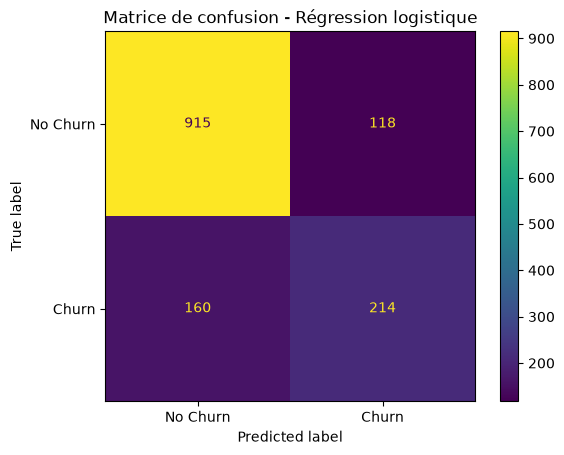

In [60]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("Matrice de confusion - Régression logistique")
plt.show()

In [61]:
print(cm)

[[915 118]
 [160 214]]


### Matrice de confusion

La matrice de confusion permet d'analyser plus précisément les erreurs du modèle.

Le modèle a correctement identifié :

- 915 clients qui sont restés dans l'entreprise ;
- 214 clients qui ont réellement churné.

En revanche, il a également produit :

- 118 faux positifs : des clients prédits comme churners alors qu'ils sont restés ;
- 160 faux négatifs : des clients ayant réellement churné mais que le modèle n'a pas détectés.

Les faux négatifs sont particulièrement importants dans ce problème, car ils correspondent à des clients à risque qui n'ont pas été identifiés par le modèle.

In [62]:
y_proba = model.predict_proba(X_test_encoded)[:, 1]

print(y_proba[:10])

[0.01761524 0.58947802 0.00444284 0.2052984  0.10459551 0.47810842
 0.02536515 0.16736417 0.66539298 0.01513634]


In [63]:
from sklearn.metrics import roc_curve, roc_auc_score

In [64]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

auc = roc_auc_score(y_test, y_proba)

print("AUC :", auc)

AUC : 0.8364260163275026


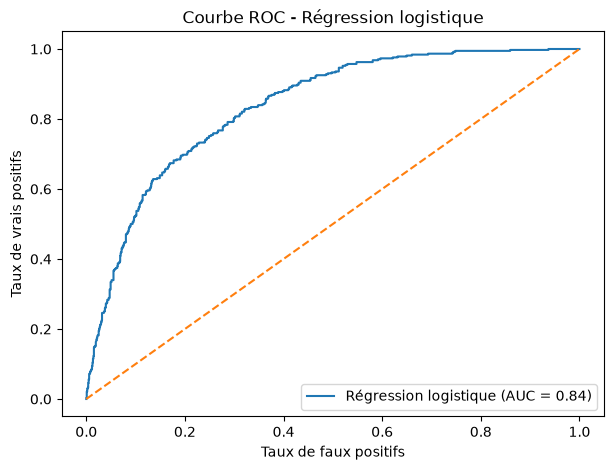

In [65]:
plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"Régression logistique (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - Régression logistique")
plt.legend()

plt.show()

In [66]:
from sklearn.tree import DecisionTreeClassifier

In [67]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

In [68]:
decision_tree.fit(X_train_encoded, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [69]:
y_pred_tree = decision_tree.predict(X_test_encoded)

In [70]:
print("Accuracy :", accuracy_score(y_test, y_pred_tree))
print("Precision :", precision_score(y_test, y_pred_tree))
print("Recall :", recall_score(y_test, y_pred_tree))
print("F1-score :", f1_score(y_test, y_pred_tree))

Accuracy : 0.7221037668798863
Precision : 0.4780361757105943
Recall : 0.4946524064171123
F1-score : 0.48620236530880423


In [71]:
y_proba_tree = decision_tree.predict_proba(X_test_encoded)[:, 1]

In [72]:
auc_tree = roc_auc_score(y_test, y_proba_tree)

print("AUC :", auc_tree)

AUC : 0.6497921530664541


### Comparaison entre la régression logistique et l'arbre de décision

La régression logistique obtient de meilleures performances que l'arbre de décision sur l'ensemble des métriques étudiées.

Elle atteint une accuracy de 80,24 %, un recall de 57,22 %, un F1-score de 60,62 % et une AUC d'environ 0,84.

L'arbre de décision obtient une accuracy de 72,21 %, un recall de 49,47 %, un F1-score de 48,62 % et une AUC d'environ 0,65.

Dans sa configuration actuelle, la régression logistique semble donc plus adaptée à notre problème de prédiction du churn. Cependant, d'autres modèles seront testés afin de rechercher de meilleures performances.

Random Forest

In [73]:
from sklearn.ensemble import RandomForestClassifier

In [74]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [75]:
random_forest.fit(X_train_encoded, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [76]:
y_pred_rf = random_forest.predict(X_test_encoded)

In [77]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision :", precision_score(y_test, y_pred_rf))
print("Recall :", recall_score(y_test, y_pred_rf))
print("F1-score :", f1_score(y_test, y_pred_rf))

Accuracy : 0.7924662402274343
Precision : 0.6375838926174496
Recall : 0.5080213903743316
F1-score : 0.5654761904761905


In [78]:
y_proba_rf = random_forest.predict_proba(X_test_encoded)[:, 1]

auc_rf = roc_auc_score(y_test, y_proba_rf)

print("AUC :", auc_rf)

AUC : 0.8129701145617095


In [79]:
from sklearn.model_selection import GridSearchCV

Définir les paramètres à tester

In [80]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [81]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [82]:
grid_search.fit(X_train_encoded, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbos

In [83]:
print("Meilleurs paramètres :")
print(grid_search.best_params_)

print("\nMeilleur score F1 en validation croisée :")
print(grid_search.best_score_)

Meilleurs paramètres :
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

Meilleur score F1 en validation croisée :
0.5836815722947003


Évaluer la Random Forest optimisée

In [84]:
grid_search.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [85]:
best_rf = grid_search.best_estimator_

In [86]:
y_pred_rf_opt = best_rf.predict(X_test_encoded)

In [87]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf_opt))
print("Precision :", precision_score(y_test, y_pred_rf_opt))
print("Recall :", recall_score(y_test, y_pred_rf_opt))
print("F1-score :", f1_score(y_test, y_pred_rf_opt))

Accuracy : 0.7953091684434968
Precision : 0.6414473684210527
Recall : 0.5213903743315508
F1-score : 0.5752212389380531


In [88]:
y_proba_rf_opt = best_rf.predict_proba(X_test_encoded)[:, 1]

auc_rf_opt = roc_auc_score(y_test, y_proba_rf_opt)

print("AUC :", auc_rf_opt)

AUC : 0.8311224252087529


### Évaluation du Random Forest optimisé

Après optimisation des hyperparamètres avec une validation croisée en 5 folds, le Random Forest obtient une accuracy de **79,53 %**, une précision de **64,14 %**, un rappel de **52,14 %**, un F1-score de **57,52 %** et une AUC de **0,831**.

L'optimisation a permis d'améliorer légèrement les performances du modèle par rapport au Random Forest initial, notamment sur le recall et le F1-score.

Cependant, la régression logistique reste le modèle le plus performant parmi les modèles testés. Elle obtient notamment un recall de **57,22 %**, un F1-score de **60,62 %** et une AUC d'environ **0,84**.

Nous allons maintenant analyser l'importance des variables afin d'identifier les caractéristiques qui contribuent le plus à la prédiction du churn.

importance des variables

In [89]:
feature_names = preprocessor.get_feature_names_out()

importances = best_rf.feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importance.head(15)

,feature,importance
42,remainder__tenure,0.141996
44,remainder__TotalCharges,0.126940
32,cat__Contract_Month-to-month,0.095825
43,remainder__MonthlyCharges,0.088324
14,cat__OnlineSecurity_No,0.055775
39,cat__PaymentMethod_Electronic check,0.041023
12,cat__InternetService_Fiber optic,0.040425
23,cat__TechSupport_No,0.040091
34,cat__Contract_Two year,0.035781
11,cat__InternetService_DSL,0.022287


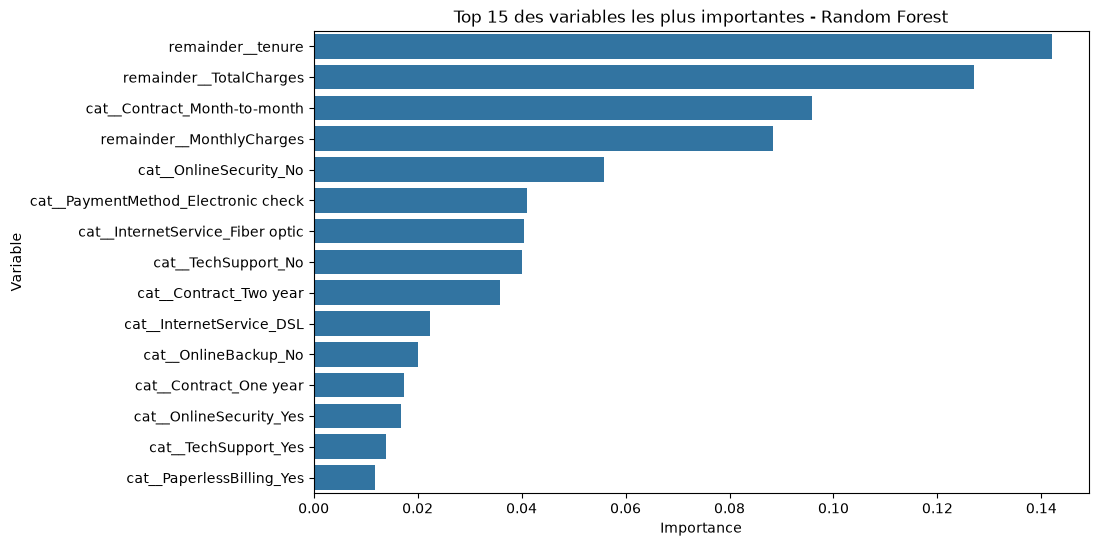

In [90]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(15),
    x="importance",
    y="feature"
)

plt.title("Top 15 des variables les plus importantes - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.show()

### Importance des variables

L'analyse de l'importance des variables du Random Forest montre que `tenure` est la variable la plus importante pour les prédictions, avec une importance de **14,20 %**, suivie de `TotalCharges` (**12,69 %**), du contrat `Month-to-month` (**9,58 %**) et de `MonthlyCharges` (**8,83 %**).

Plusieurs variables liées aux services proposés au client apparaissent également parmi les variables importantes, notamment l'absence de `OnlineSecurity`, l'utilisation du paiement par `Electronic check`, le service Internet `Fiber optic` et l'absence de `TechSupport`.

Ces résultats permettent d'identifier les principales caractéristiques utilisées par le modèle pour prédire le churn. Ils sont également cohérents avec plusieurs tendances observées lors de l'analyse exploratoire.

In [91]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_columns = X.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = X.select_dtypes(include="str").columns

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

In [92]:
print("Variables numériques :", list(numeric_columns))
print("Variables catégorielles :", list(categorical_columns))

Variables numériques : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Variables catégorielles : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [93]:
X_train_scaled = preprocessor_scaled.fit_transform(X_train)
X_test_scaled = preprocessor_scaled.transform(X_test)

In [94]:
print("X_train :", X_train_scaled.shape)
print("X_test :", X_test_scaled.shape)

X_train : (5625, 45)
X_test : (1407, 45)


In [95]:
from sklearn.linear_model import LogisticRegression

logistic_scaled = LogisticRegression(max_iter=1000)

logistic_scaled.fit(X_train_scaled, y_train)

y_pred_log_scaled = logistic_scaled.predict(X_test_scaled)

In [96]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_log_scaled))
print("Precision :", precision_score(y_test, y_pred_log_scaled))
print("Recall :", recall_score(y_test, y_pred_log_scaled))
print("F1-score :", f1_score(y_test, y_pred_log_scaled))

y_proba_log_scaled = logistic_scaled.predict_proba(X_test_scaled)[:, 1]

print("AUC :", roc_auc_score(y_test, y_proba_log_scaled))

Accuracy : 0.8038379530916845
Precision : 0.6484848484848484
Recall : 0.5721925133689839
F1-score : 0.6079545454545454
AUC : 0.8359290473207676


### Régression logistique avec normalisation

Afin d'améliorer la préparation des données, les variables numériques ont été standardisées à l'aide de `StandardScaler`.

Après normalisation, la régression logistique obtient une accuracy de **80,38 %**, une précision de **64,85 %**, un recall de **57,22 %**, un F1-score de **60,80 %** et une AUC de **0,836**.

Les performances sont très proches du modèle initial. La normalisation apporte une légère amélioration de l'accuracy, de la précision et du F1-score, tandis que le recall reste identique.

Le modèle normalisé constitue donc une meilleure base pour poursuivre l'optimisation de la régression logistique.

optimiser la régression logistique

In [97]:
from sklearn.model_selection import GridSearchCV

param_grid_log = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

grid_log = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=param_grid_log,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_log.fit(X_train_scaled, y_train)

print("Meilleurs paramètres :", grid_log.best_params_)
print("Meilleur F1 en validation croisée :", grid_log.best_score_)

Meilleurs paramètres : {'C': 1, 'solver': 'liblinear'}
Meilleur F1 en validation croisée : 0.5964817699878876


### Optimisation de la régression logistique

Une recherche par grille (`GridSearchCV`) avec une validation croisée en 5 folds a été réalisée afin de rechercher les meilleurs hyperparamètres de la régression logistique.

Les meilleurs paramètres obtenus sont :

- `C = 1`
- `solver = liblinear`

Le meilleur F1-score moyen obtenu lors de la validation croisée est de **59,65 %**.

Ces paramètres seront utilisés pour évaluer le modèle optimisé sur le jeu de test.

In [98]:
best_log = grid_log.best_estimator_

y_pred_log_opt = best_log.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred_log_opt))
print("Precision :", precision_score(y_test, y_pred_log_opt))
print("Recall :", recall_score(y_test, y_pred_log_opt))
print("F1-score :", f1_score(y_test, y_pred_log_opt))

y_proba_log_opt = best_log.predict_proba(X_test_scaled)[:, 1]

auc_log_opt = roc_auc_score(y_test, y_proba_log_opt)

print("AUC :", auc_log_opt)

Accuracy : 0.8038379530916845
Precision : 0.6484848484848484
Recall : 0.5721925133689839
F1-score : 0.6079545454545454
AUC : 0.8359342240812544


### Évaluation de la régression logistique optimisée

Le modèle optimisé avec `C = 1` et `solver = liblinear` obtient sur le jeu de test une accuracy de **80,38 %**, une précision de **64,85 %**, un recall de **57,22 %**, un F1-score de **60,80 %** et une AUC de **0,836**.

Les performances sont quasiment identiques à celles obtenues avant l'optimisation. L'optimisation des hyperparamètres n'a donc pas apporté d'amélioration significative sur le jeu de test.

La régression logistique reste néanmoins le modèle le plus performant parmi les modèles testés jusqu'à présent.

In [99]:
results = pd.DataFrame({
    "Modèle": [
        "Régression logistique",
        "Arbre de décision",
        "Random Forest",
        "Random Forest optimisé",
        "Régression logistique optimisée"
    ],
    "Accuracy": [
        0.8024,
        0.7221,
        0.7925,
        0.7953,
        0.8038
    ],
    "Precision": [
        0.6446,
        0.4780,
        0.6376,
        0.6414,
        0.6485
    ],
    "Recall": [
        0.5722,
        0.4947,
        0.5080,
        0.5214,
        0.5722
    ],
    "F1-score": [
        0.6062,
        0.4862,
        0.5655,
        0.5752,
        0.6080
    ],
    "AUC": [
        0.8364,
        0.6498,
        0.8130,
        0.8311,
        0.8359
    ]
})

results

,Modèle,Accuracy,Precision,Recall,F1-score,AUC
0,Régression logistique,0.8024,0.6446,0.5722,0.6062,0.8364
1,Arbre de décision,0.7221,0.4780,0.4947,0.4862,0.6498
2,Random Forest,0.7925,0.6376,0.5080,0.5655,0.8130
3,Random Forest optimisé,0.7953,0.6414,0.5214,0.5752,0.8311
4,Régression logistique optimisée,0.8038,0.6485,0.5722,0.6080,0.8359


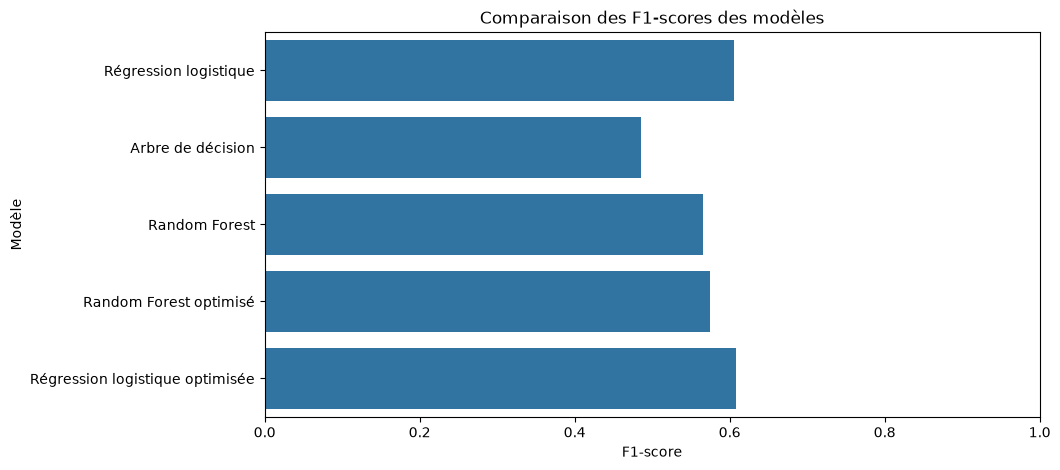

In [100]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results,
    x="F1-score",
    y="Modèle"
)

plt.title("Comparaison des F1-scores des modèles")
plt.xlabel("F1-score")
plt.ylabel("Modèle")
plt.xlim(0, 1)
plt.show()

### Comparaison des F1-scores

La comparaison des F1-scores montre que la **régression logistique optimisée** obtient le meilleur résultat avec un F1-score de **60,80 %**.

Elle est suivie par la régression logistique initiale avec **60,62 %**, puis par le Random Forest optimisé avec **57,52 %**.

L'arbre de décision obtient le score le plus faible avec **48,62 %**.

La régression logistique optimisée apparaît donc comme le modèle le plus performant selon le F1-score. Cependant, la sélection finale du modèle prendra également en compte le recall et l'AUC, qui sont particulièrement importants dans un problème de prédiction du churn.

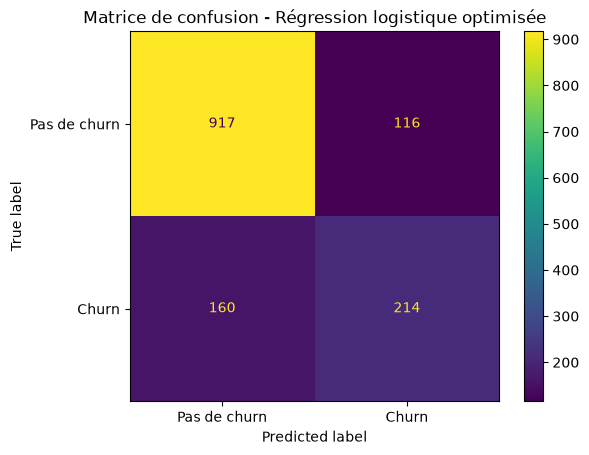

In [101]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_log_opt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Pas de churn", "Churn"]
)

disp.plot()

plt.title("Matrice de confusion - Régression logistique optimisée")
plt.show()

### Matrice de confusion

La matrice de confusion de la régression logistique optimisée présente :

- **917 vrais négatifs** : clients restés correctement identifiés ;
- **116 faux positifs** : clients restés mais prédits comme churners ;
- **160 faux négatifs** : clients ayant churné mais non détectés ;
- **214 vrais positifs** : clients ayant churné et correctement détectés.

Le modèle identifie ainsi **214 clients ayant réellement churné sur 374**, soit un recall de **57,22 %**.

Les 160 faux négatifs montrent qu'une partie des clients qui quittent réellement l'entreprise n'est pas détectée par le modèle. L'amélioration de cette détection constitue donc un enjeu important pour une éventuelle utilisation opérationnelle du modèle.

In [102]:
print(confusion_matrix(y_test, y_pred_log_opt))

[[917 116]
 [160 214]]


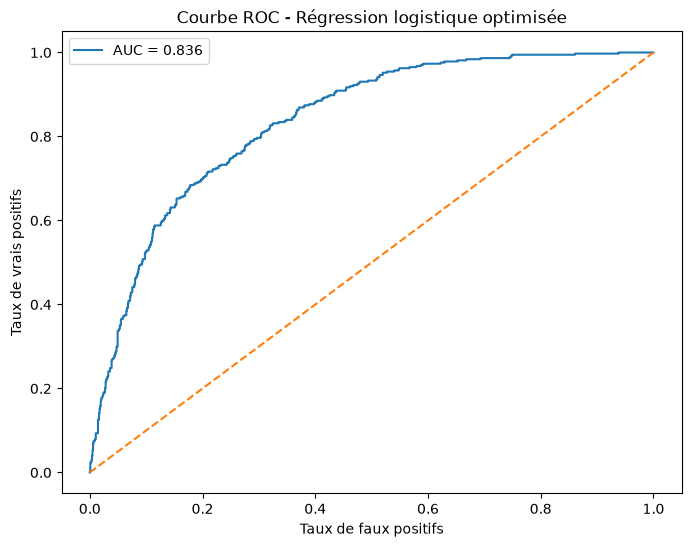

AUC : 0.8359342240812544


In [103]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_proba_log_opt)

auc_log_opt = roc_auc_score(y_test, y_proba_log_opt)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"AUC = {auc_log_opt:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - Régression logistique optimisée")
plt.legend()
plt.show()

print("AUC :", auc_log_opt)

comparaison des AUC

In [104]:
auc_results = pd.DataFrame({
    "Modèle": [
        "Régression logistique",
        "Arbre de décision",
        "Random Forest",
        "Random Forest optimisé",
        "Régression logistique optimisée"
    ],
    "AUC": [
        0.8364,
        0.6498,
        0.8130,
        0.8311,
        0.8359
    ]
})

auc_results

,Modèle,AUC
0,Régression logistique,0.8364
1,Arbre de décision,0.6498
2,Random Forest,0.8130
3,Random Forest optimisé,0.8311
4,Régression logistique optimisée,0.8359


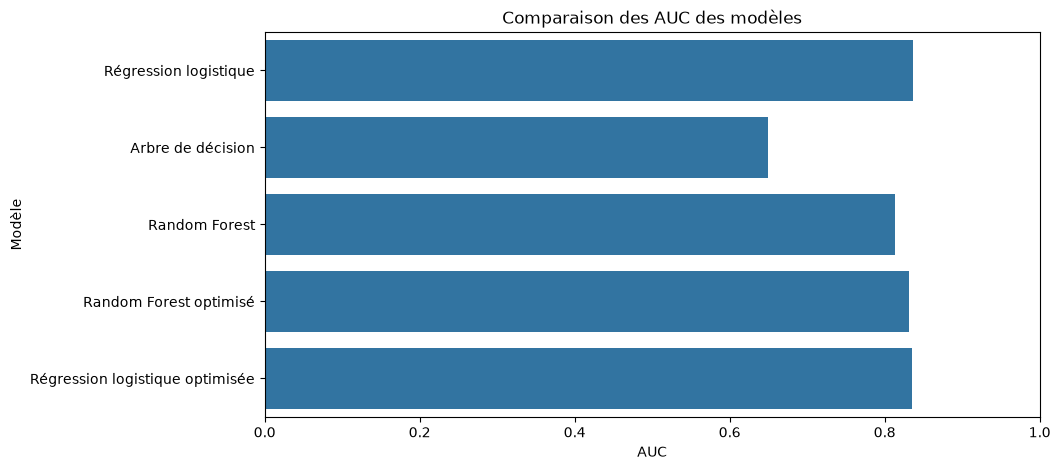

In [105]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=auc_results,
    x="AUC",
    y="Modèle"
)

plt.title("Comparaison des AUC des modèles")
plt.xlabel("AUC")
plt.ylabel("Modèle")
plt.xlim(0, 1)
plt.show()

In [106]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_log_opt,
    target_names=["Pas de churn", "Churn"]
))

              precision    recall  f1-score   support

Pas de churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



### Rapport de classification

Le rapport de classification montre que le modèle obtient de bonnes performances pour la classe `Pas de churn`, avec un F1-score de **87 %** et un recall de **89 %**.

Pour la classe `Churn`, le modèle obtient une précision de **65 %**, un recall de **57 %** et un F1-score de **61 %**.

Le recall de 57 % signifie que le modèle détecte correctement un peu plus de la moitié des clients ayant réellement quitté l'entreprise. Cependant, une partie des clients churners reste non détectée.

L'accuracy globale du modèle est de **80 %**. Toutefois, dans le contexte de la prédiction du churn, le recall et le F1-score de la classe `Churn` sont particulièrement importants, car l'objectif est notamment d'identifier les clients susceptibles de quitter l'entreprise.

In [107]:
threshold = 0.40

y_pred_threshold = (y_proba_log_opt >= threshold).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred_threshold))
print("Precision :", precision_score(y_test, y_pred_threshold))
print("Recall :", recall_score(y_test, y_pred_threshold))
print("F1-score :", f1_score(y_test, y_pred_threshold))

Accuracy : 0.7839374555792467
Precision : 0.579185520361991
Recall : 0.6844919786096256
F1-score : 0.6274509803921569


### Optimisation du seuil de décision

Par défaut, la régression logistique utilise un seuil de 0,50 pour déterminer la classe prédite.

Afin d'améliorer la détection des clients susceptibles de churner, nous avons testé un seuil de **0,40**.

Avec ce nouveau seuil, le recall passe de **57,22 % à 68,45 %**. Le modèle détecte donc une proportion plus importante des clients ayant réellement churné.

En contrepartie, la précision diminue de **64,85 % à 57,92 %** et l'accuracy passe de **80,38 % à 78,39 %**.

Cependant, le F1-score augmente de **60,80 % à 62,75 %**. Le seuil de 0,40 permet donc d'obtenir un meilleur équilibre entre la précision et le rappel, tout en améliorant la détection des clients churners.

Dans un contexte où l'entreprise souhaite identifier le maximum de clients à risque afin de pouvoir mettre en place des actions de fidélisation, ce seuil peut être particulièrement intéressant.

trouver le meilleur seuil

In [108]:
thresholds = np.arange(0.20, 0.71, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_temp = (y_proba_log_opt >= threshold).astype(int)

    threshold_results.append({
        "Seuil": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_temp),
        "Precision": precision_score(y_test, y_pred_temp),
        "Recall": recall_score(y_test, y_pred_temp),
        "F1-score": f1_score(y_test, y_pred_temp)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Seuil,Accuracy,Precision,Recall,F1-score
0,0.20,0.691542,0.457746,0.868984,0.599631
1,0.25,0.719972,0.484127,0.815508,0.607570
2,0.30,0.743426,0.511712,0.759358,0.611410
3,0.35,0.765458,0.544534,0.719251,0.619816
4,0.40,0.783937,0.579186,0.684492,0.627451
5,0.45,0.791045,0.602041,0.631016,0.616188
6,0.50,0.803838,0.648485,0.572193,0.607955
7,0.55,0.798863,0.667897,0.483957,0.561240
8,0.60,0.788202,0.679245,0.385027,0.491468
9,0.65,0.776830,0.694805,0.286096,0.405303


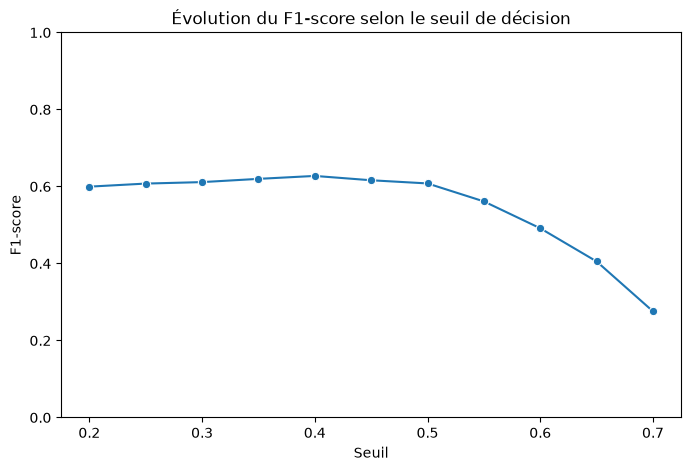

In [109]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=threshold_df,
    x="Seuil",
    y="F1-score",
    marker="o"
)

plt.title("Évolution du F1-score selon le seuil de décision")
plt.xlabel("Seuil")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.show()

In [110]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1-score"].idxmax()
]

print(best_threshold_row)

Seuil        0.400000
Accuracy     0.783937
Precision    0.579186
Recall       0.684492
F1-score     0.627451
Name: 4, dtype: float64


### Sélection du seuil optimal

Plusieurs seuils de décision ont été testés afin d'optimiser les performances de la régression logistique.

Le seuil de **0,40** obtient le meilleur F1-score parmi les seuils testés, avec une valeur de **62,75 %**.

À ce seuil, le modèle obtient :

- Accuracy : **78,39 %**
- Precision : **57,92 %**
- Recall : **68,45 %**
- F1-score : **62,75 %**

Le passage d'un seuil de 0,50 à 0,40 permet d'améliorer significativement le recall, qui passe de **57,22 % à 68,45 %**.

Ce choix est pertinent dans le contexte du churn, car l'entreprise peut privilégier la détection d'un maximum de clients à risque afin de mettre en place des actions de fidélisation.

Faisons le tableau final

In [111]:
final_results = pd.DataFrame({
    "Modèle": [
        "Régression logistique",
        "Arbre de décision",
        "Random Forest",
        "Random Forest optimisé",
        "Régression logistique optimisée",
        "Logistique optimisée + seuil 0.40"
    ],
    "Accuracy": [
        0.8024,
        0.7221,
        0.7925,
        0.7953,
        0.8038,
        0.7839
    ],
    "Precision": [
        0.6446,
        0.4780,
        0.6376,
        0.6414,
        0.6485,
        0.5792
    ],
    "Recall": [
        0.5722,
        0.4947,
        0.5080,
        0.5214,
        0.5722,
        0.6845
    ],
    "F1-score": [
        0.6062,
        0.4862,
        0.5655,
        0.5752,
        0.6080,
        0.6275
    ],
    "AUC": [
        0.8364,
        0.6498,
        0.8130,
        0.8311,
        0.8359,
        0.8359
    ]
})

final_results

,Modèle,Accuracy,Precision,Recall,F1-score,AUC
0,Régression logistique,0.8024,0.6446,0.5722,0.6062,0.8364
1,Arbre de décision,0.7221,0.4780,0.4947,0.4862,0.6498
2,Random Forest,0.7925,0.6376,0.5080,0.5655,0.8130
3,Random Forest optimisé,0.7953,0.6414,0.5214,0.5752,0.8311
4,Régression logistique optimisée,0.8038,0.6485,0.5722,0.6080,0.8359
5,Logistique optimisée + seuil 0.40,0.7839,0.5792,0.6845,0.6275,0.8359


## Conclusion de la modélisation

Plusieurs modèles de classification ont été entraînés et comparés afin de prédire le churn des clients : la régression logistique, l'arbre de décision et le Random Forest.

La régression logistique a obtenu les meilleures performances parmi les modèles de base, avec une AUC d'environ **0,84** et un F1-score de **60,62 %**.

Le Random Forest a ensuite été optimisé à l'aide d'une recherche par grille (`GridSearchCV`). Malgré une légère amélioration de ses performances, il reste moins performant que la régression logistique sur les métriques étudiées.

La régression logistique a également été optimisée avec une normalisation des variables numériques et une recherche des meilleurs hyperparamètres. Enfin, différents seuils de décision ont été testés.

Le seuil de **0,40** a permis d'obtenir le meilleur F1-score parmi les seuils testés, avec **62,75 %**, ainsi qu'un recall de **68,45 %**.

Ce modèle est donc retenu comme modèle final, car dans le contexte de la prédiction du churn, la détection des clients susceptibles de quitter l'entreprise constitue un objectif prioritaire.

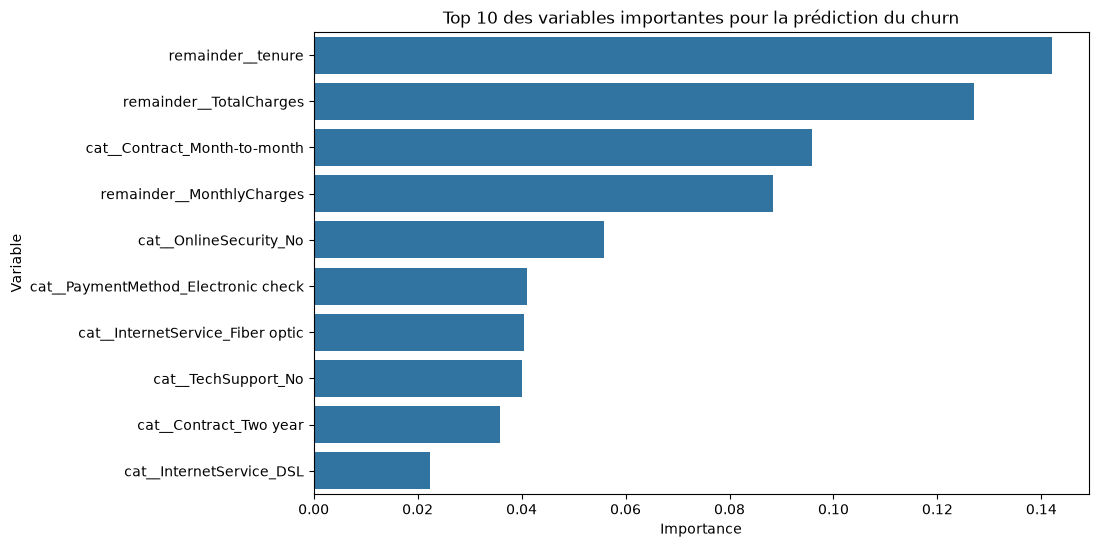

In [112]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title("Top 10 des variables importantes pour la prédiction du churn")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.show()

## Analyse des variables importantes

L'analyse de l'importance des variables du Random Forest montre que l'ancienneté du client (`tenure`) constitue la variable la plus importante pour les prédictions, suivie du montant total facturé (`TotalCharges`), du type de contrat et des frais mensuels.

Plusieurs variables liées aux services et aux modalités de paiement apparaissent également parmi les variables importantes, notamment l'absence de sécurité en ligne, le paiement par chèque électronique, l'utilisation de la fibre optique et l'absence de support technique.

Ces résultats sont cohérents avec l'analyse exploratoire réalisée précédemment. Le contrat mensuel et la fibre optique présentaient notamment des taux de churn élevés.

Il est important de préciser que l'importance d'une variable indique son utilité pour les prédictions du modèle et ne signifie pas qu'elle constitue nécessairement une cause directe du churn.

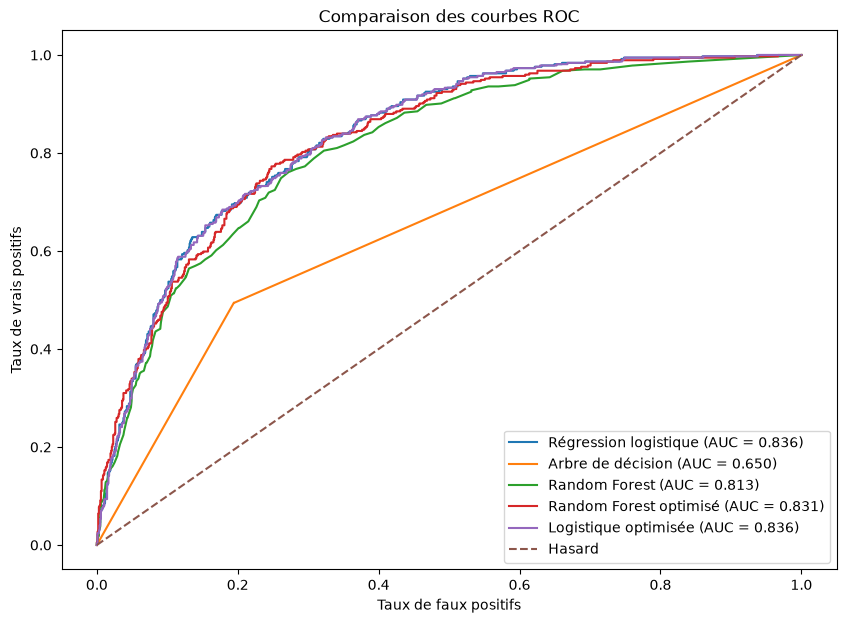

In [113]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilités prédites
y_proba_log = model.predict_proba(X_test_encoded)[:, 1]
y_proba_tree = decision_tree.predict_proba(X_test_encoded)[:, 1]
y_proba_rf = random_forest.predict_proba(X_test_encoded)[:, 1]
y_proba_rf_opt = best_rf.predict_proba(X_test_encoded)[:, 1]
y_proba_log_opt = best_log.predict_proba(X_test_scaled)[:, 1]

# Calcul des courbes ROC
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_proba_tree)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_rf_opt, tpr_rf_opt, _ = roc_curve(y_test, y_proba_rf_opt)
fpr_log_opt, tpr_log_opt, _ = roc_curve(y_test, y_proba_log_opt)

# Calcul des AUC
auc_log = roc_auc_score(y_test, y_proba_log)
auc_tree = roc_auc_score(y_test, y_proba_tree)
auc_rf = roc_auc_score(y_test, y_proba_rf)
auc_rf_opt = roc_auc_score(y_test, y_proba_rf_opt)
auc_log_opt = roc_auc_score(y_test, y_proba_log_opt)

# Graphique
plt.figure(figsize=(10, 7))

plt.plot(fpr_log, tpr_log, label=f"Régression logistique (AUC = {auc_log:.3f})")
plt.plot(fpr_tree, tpr_tree, label=f"Arbre de décision (AUC = {auc_tree:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_rf_opt, tpr_rf_opt, label=f"Random Forest optimisé (AUC = {auc_rf_opt:.3f})")
plt.plot(fpr_log_opt, tpr_log_opt, label=f"Logistique optimisée (AUC = {auc_log_opt:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Hasard")

plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Comparaison des courbes ROC")
plt.legend()
plt.show()

### Comparaison des courbes ROC

La comparaison des courbes ROC confirme les résultats obtenus précédemment.

Les deux modèles de régression logistique présentent les meilleures AUC, avec des valeurs proches de **0,84**. Le Random Forest optimisé obtient également une bonne AUC de **0,831**.

L'arbre de décision présente une AUC nettement plus faible, de **0,650**.

Les modèles de régression logistique semblent donc offrir la meilleure capacité à distinguer les clients ayant churné de ceux n'ayant pas churné.

## Limites du modèle

Le modèle final présente de bonnes performances pour la prédiction du churn, mais il possède certaines limites.

Avec un seuil de décision de 0,40, le recall atteint **68,45 %**, ce qui permet de détecter une proportion importante des clients ayant réellement churné. Cependant, la précision diminue à **57,92 %**, ce qui signifie qu'une partie des clients identifiés comme étant à risque ne churnera finalement pas.

Le modèle présente également des faux négatifs : certains clients qui quittent réellement l'entreprise ne sont pas détectés. Cela peut entraîner la perte d'opportunités de fidélisation.

Enfin, les performances du modèle dépendent des variables disponibles dans le dataset. Certaines informations pouvant influencer le comportement des clients peuvent ne pas être présentes dans les données.

Le seuil de décision devra donc être adapté au contexte métier et au coût associé aux faux positifs et aux faux négatifs.

la conclusion générale

# Conclusion générale

L'objectif de ce projet était de développer un modèle permettant de prédire le churn des clients à partir de leurs caractéristiques et de leur comportement.

Dans un premier temps, les données ont été explorées et nettoyées. L'analyse a notamment permis d'identifier un déséquilibre entre les deux classes : environ **73,4 % des clients n'ont pas churné**, contre **26,6 % ayant churné**.

L'analyse exploratoire a également mis en évidence plusieurs facteurs associés au churn, notamment le type de contrat, le type de service Internet et les caractéristiques liées à la facturation.

Plusieurs modèles de classification ont ensuite été testés : la régression logistique, l'arbre de décision et le Random Forest. Les modèles ont été évalués à l'aide de l'accuracy, de la précision, du recall, du F1-score et de l'AUC.

La régression logistique s'est révélée être le modèle le plus performant parmi les modèles testés. Une optimisation des hyperparamètres ainsi qu'une normalisation des variables numériques ont été réalisées.

Enfin, différents seuils de décision ont été testés. Le seuil de **0,40** a obtenu le meilleur F1-score parmi les seuils étudiés, avec un F1-score de **62,75 %** et un recall de **68,45 %**.

Ce choix permet de mieux détecter les clients susceptibles de quitter l'entreprise. Dans un contexte métier, ce modèle pourrait donc être utilisé comme outil d'aide à la décision afin d'identifier les clients présentant un risque de churn et de permettre à l'entreprise de mettre en place des actions de fidélisation.

Cependant, le modèle présente encore des limites, notamment les faux positifs et les faux négatifs. Le seuil de décision pourrait donc être ajusté selon le coût réel des différentes erreurs pour l'entreprise.

# Recommandations métier

À partir des résultats obtenus, plusieurs actions peuvent être proposées à l'entreprise.

Tout d'abord, le modèle peut être utilisé pour identifier les clients présentant une probabilité élevée de churn et permettre aux équipes commerciales de prioriser leurs actions de fidélisation.

Une attention particulière peut être portée aux clients ayant un contrat `Month-to-month`, qui présentent un taux de churn élevé dans l'analyse exploratoire. Des offres de fidélisation ou des avantages liés à des contrats de plus longue durée pourraient être proposés.

Les clients utilisant certains services, notamment la fibre optique, peuvent également faire l'objet d'une analyse plus approfondie afin d'identifier les éventuels problèmes liés au prix, à la qualité du service ou à la satisfaction client.

Enfin, un tableau de bord pourrait être développé afin de permettre aux équipes de suivre les indicateurs de churn et d'identifier rapidement les clients à risque.

Le modèle doit toutefois être considéré comme un outil d'aide à la décision et non comme une prédiction certaine du comportement futur des clients.

le dashboard

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "vscode"


In [12]:
import pandas as pd
import numpy as np
import plotly.express as px
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
dataset_path = project_root / "data" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Lecture + nettoyage minimal pour pouvoir reconstruire df depuis la cellule finale
# sans dépendre des variables en mémoire du noyau

df = pd.read_csv(dataset_path)
df["TotalCharges"] = df["TotalCharges"].replace("", np.nan)
df = df.dropna(subset=["TotalCharges"])
df["Churn"] = df["Churn"].astype(str)

fig = px.pie(
    df,
    names="Churn",
    title="Répartition des clients selon le churn"
)

reports_dir = project_root / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)
fig.write_html(reports_dir / "churn_pie.html")

print(f"Figure Plotly sauvegardée dans : {reports_dir / 'churn_pie.html'}")


Figure Plotly sauvegardée dans : c:\Users\T-Plug\Desktop\Projet_3_Churn\reports\churn_pie.html


In [10]:
import sys
import nbformat
print(sys.executable)
print(nbformat.__version__)
print(nbformat.__file__)


c:\Program Files\Python313\python.exe
5.11.1
C:\Users\T-Plug\AppData\Roaming\Python\Python313\site-packages\nbformat\__init__.py


In [16]:
import pandas as pd
import numpy as np
import plotly.express as px
from plotly.subplots import make_subplots
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
dataset_path = project_root / "data" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(dataset_path)
df["TotalCharges"] = df["TotalCharges"].replace("", np.nan)
df = df.dropna(subset=["TotalCharges"])
df["Churn"] = df["Churn"].astype(str)

fig_pie = px.pie(
    df,
    names="Churn",
    title="Répartition des clients selon le churn"
)

fig_hist = px.histogram(
    df,
    x="Contract",
    color="Churn",
    barmode="group",
    title="Churn selon le type de contrat",
    text_auto=True
)

# Dashboard partagé des deux dernieres figures

dashboard = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "pie"}, {"type": "xy"}]],
    subplot_titles=(
        "Répartition des clients selon le churn",
        "Churn selon le type de contrat"
    ),
    horizontal_spacing=0.12
)

dashboard.add_trace(fig_pie.data[0], row=1, col=1)
for trace in fig_hist.data:
    dashboard.add_trace(trace, row=1, col=2)

dashboard.update_layout(
    title="Dashboard Churn",
    template="plotly_white",
    height=700,
    width=1400,
    showlegend=True
)

reports_dir = project_root / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)
dashboard.write_html(reports_dir / "churn_dashboard.html")

print(f"Dashboard Plotly sauvegardé dans : {reports_dir / 'churn_dashboard.html'}")


Dashboard Plotly sauvegardé dans : c:\Users\T-Plug\Desktop\Projet_3_Churn\reports\churn_dashboard.html


### Analyse

La visualisation montre une différence importante du churn selon le type de contrat.

Les clients ayant un contrat `Month-to-month` sont beaucoup plus représentés parmi les clients ayant churné que ceux ayant un contrat d'un an ou de deux ans.

Cette variable apparaît également parmi les variables importantes du modèle, ce qui confirme son intérêt pour la prédiction du churn.